In [1]:
from google.colab import drive
drive.mount('/content/drive') #連雲端硬碟

import pandas as pd
googlepath='/content/drive/MyDrive/巨資雲端技術/' #路徑到指定資料夾

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import matplotlib.pyplot as plt

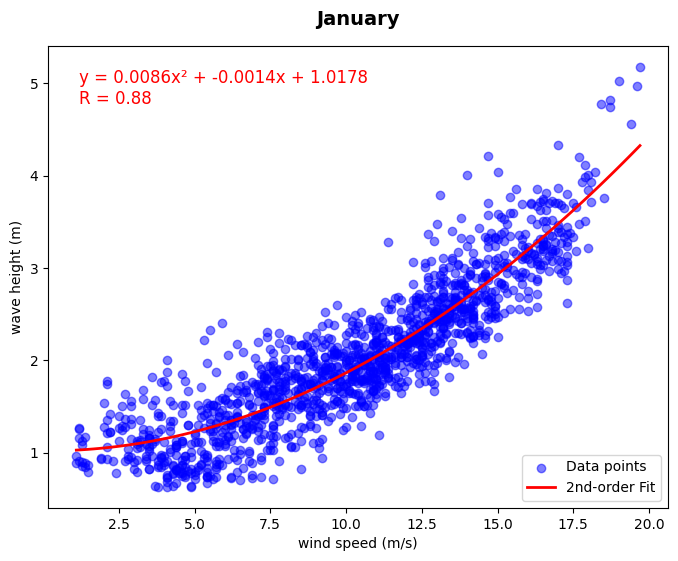

In [3]:
# 1. 讀取檔案
df_1 = pd.read_csv(googlepath + "1月.csv")
df_clean = df_1[["風速", "波高"]].dropna()
x = df_clean["風速"].values
y = df_clean["波高"].values

# 2. 計算 Excel 版本的 CORREL()
excel_r = df_clean["風速"].corr(df_clean["波高"])

# 3. 計算 二次回歸方程式
coefficients = np.polyfit(x, y, deg=2)
p = np.poly1d(coefficients)

# 4. 產生平滑的回歸線數據
x_line = np.linspace(x.min(), x.max(), 100)
y_line = p(x_line)

# 5. 畫圖
fig, ax = plt.subplots(figsize=(8, 6))

# 畫出散佈圖
ax.scatter(x, y, color="blue", alpha=0.5, label="Data points")

# 畫出二次回歸線
ax.plot(x_line, y_line, color="red", linewidth=2, label="2nd-order Fit")

# 6. 只顯示二次回歸方程式與 Excel 的 R 值（保留兩位小數）
equation_str = (
    f"y = {coefficients[0]:.4f}x² + {coefficients[1]:.4f}x + {coefficients[2]:.4f}\n"
    f"R = {excel_r:.2f}\n"
)

graph_title = "January" #圖名
ax.set_title(graph_title, fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("wind speed (m/s)")
ax.set_ylabel("wave height (m)")

ax.text(
    0.05,
    0.95,
    equation_str,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="top",
    color="red",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
)

plt.legend()
plt.show()